## Nello svolgimento del notebook ho lasciato le vecchie celle di testo e codice precedenti rispetto alla correzione in modo da avere traccia di quanto rivisto dopo il feedback ricevuto dal docente.

# INSTALLAZIONE AMBIENTE E SETUP DIPENDENZE

In [1]:
!git clone https://github.com/Limmen/gym-idsgame.git
%cd gym-idsgame
!pip install -e .
!pip install gymnasium torch matplotlib numpy pyyaml

fatal: destination path 'gym-idsgame' already exists and is not an empty directory.
/content/gym-idsgame
Obtaining file:///content/gym-idsgame
  Preparing metadata (setup.py) ... done
  Attempting uninstall: gym_idsgame
    Found existing installation: gym_idsgame 1.0.12
    Uninstalling gym_idsgame-1.0.12:
      Successfully uninstalled gym_idsgame-1.0.12
  Running setup.py develop for gym_idsgame


In [2]:
import gymnasium as gym
import gym_idsgame
import torch
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import deque
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Configuro il dispositivo (CPU o GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo in uso: {device}")

Dispositivo in uso: cpu


# ESPLORAZIONE DELL'AMBIENTE E ANALISI DELLO STATO

In questa fase iniziale, analizzo come l'ambiente gym-idsgame v3 rappresenta il problema della cyber security applicato alla rete sanitaria. Relativamente alla correzione del docente circa la mia precedente consegna, ho implementato un wrapper che normalizza le API dell'ambiente, garantendo robustezza e correttezza logica.

Le componenti critiche sono le seguenti:

- Stato: rappresenta la configurazione della rete. Per garantire la compatibilità sia con la Q-Table di SARSA che con la rete neurale DDQN, implemento una funzione di flattening che trasforma la matrice 3x11 in un vettore unidimensionale, eliminando le inconsistenze nei formati di output tra reset() e step().

- Azioni: l'agente difensore gestisce contromisure all'interno di uno spazio di 30 azioni. L'interazione avviene ora in modo standardizzato tramite la funzione patched_step.

- Reward: a differenza della versione precedente, il sistema ora estrae esplicitamente l'indice 1 della tupla di reward restituita dall'ambiente. Questo assicura che l'agente riceva il feedback relativo alle performance del difensore e non dell'attaccante, permettendo una convergenza coerente dell'algoritmo verso una strategia di protezione efficace.

L'introduzione delle funzioni patched_reset e patched_step permette di gestire le API legacy in modo centralizzato, rendendo il codice più modulare e leggibile.

In [3]:
# Definisco le versioni aggiornate (v3) come richiesto dalla correzione
ENV_NAME_RANDOM = "idsgame-random_attack-v3"
ENV_NAME_MAXIMAL = "idsgame-maximal_attack-v3"

def patched_reset(env):
    """
    Normalizzo il reset per gestire API legacy e tuple.
    Utilizzo env.unwrapped.reset() per evitare che Gymansium passi argomenti extra come "options" che causano un TypeError.
    Risolvo il problema dei formati differenti tra versioni.
    """
    obs = env.unwrapped.reset()
    if isinstance(obs, tuple):
        obs = obs[0]
    """
    Sincronizzo manualmente lo stato interno del wrapper se necessario

    """
    if hasattr(env, "_has_reset"):
        env._has_reset = True

    return np.array(obs).flatten()

def patched_step(env, action):
    """
    Normalizzo lo step e correggo l'errore del reward.

    """
    # Formato richiesto per agire come difensore (uso unwrapped per coerenza con il reset)
    results = env.unwrapped.step((None, action))
    obs, reward, done, info = results[:4]

    # Estraggo il reward del difensore (con indice 1)
    if isinstance(reward, (tuple, list, np.ndarray)):
        defender_reward = float(reward[1])
    else:
        # Fallback nel caso l'ambiente restituisca un valore singolo
        defender_reward = float(reward)

    # Normalizzo lo stato (appiattimento per la rete neurale)
    obs = np.array(obs).flatten()
    return obs, defender_reward, bool(done), info

# APPROFONDIMENTO CARATTERIZZAZIONE INIZIALE
env_test = gym.make(ENV_NAME_RANDOM)

# Test del Reset
s0 = patched_reset(env_test)
print("ANALISI OUTPUT RESET")
print(f"Formato osservazione iniziale: {s0.shape}")
print(f"Esempio valori stato (normalizzato): {s0[:5]}...")

# Test dello Step
a_sample = env_test.action_space.sample()
s1, r, d, i = patched_step(env_test, a_sample)

print("\nANALISI OUTPUT STEP")
print(f"Azione campionata: {a_sample}")
print(f"Reward ricevuto (Difensore - indice [1]): {r}")
print(f"Stato successivo (Flattened): {s1.shape}")
print(f"Episodio terminato: {d}")

# Verifica finale requisiti richiesti dalla correzione
print("\nVERIFICA REQUISITI")
print(f"Ambiente: {ENV_NAME_RANDOM} (Versione aggiornata)")
print(f"Gestione API: Wrapper patched_reset/step implementati")
print(f"Correttezza Logica: Reward estratto correttamente per il difensore")

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment idsgame-random_attack-v3 is out of date. You should consider upgrading to version `v21`.
  logger.deprecation(


ANALISI OUTPUT RESET
Formato osservazione iniziale: (88,)
Esempio valori stato (normalizzato): [0. 0. 0. 0. 0.]...

ANALISI OUTPUT STEP
Azione campionata: 6
Reward ricevuto (Difensore - indice [1]): 0.0
Stato successivo (Flattened): (88,)
Episodio terminato: False

VERIFICA REQUISITI
Ambiente: idsgame-random_attack-v3 (Versione aggiornata)
Gestione API: Wrapper patched_reset/step implementati
Correttezza Logica: Reward estratto correttamente per il difensore


''' VECCHIA CELLA DI TESTO '''

ESPLORAZIONE DELL'AMBIENTE E ANALISI DELLO STATO

Inizio il mio progetto andando ad analizzare come l'ambiente gym-idsgame rappresenta il problema della cyber security. In questa fase vado quindi ad approfondire tre componenti chiave:

-Lo Stato (State Space): rappresenta la configurazione attuale della rete sanitaria. Ogni valore all'interno del tensore di stato indica se un nodo è sicuro, vulnerabile o compromesso.

-Le Azioni (Action Space): vanno ad identificare le contromisure che l'agente difensore può intraprendere (ad esempio: installare patch, monitorare il traffico o non intervenire).

-Il Reward (Feedback): è il segnale scalare che guida l'apprendimento. Un reward positivo indica una difesa efficace, mentre uno negativo indica una violazione dei dati sensibili dei pazienti.

Con questo codice, vado a verificare il formato dei dati per capire se è necessario un preprocessing dei dati prima di passarli alla Q-Table di SARSA o alla rete neurale di DDQN.


In [4]:
''' VECCHIA CELLA DI CODICE PRECEDENTE RISPETTO ALLA CORREZIONE

# Definisco il nome dell'ambiente (come richiesto, scenario random attack)
env_name = "idsgame-random_attack-v0"

# Creo l'istanza dell'ambiente
env = gym.make(env_name)

# Resetto l'ambiente per ottenere lo stato iniziale (uso Unwrapped per evitare che Gymnasium passi argomenti extra come "options" che mi causano un TypeError nell'ambiente idsgame; avviso il wrapper che il reset è avvenuto impostando _has_reset (se presente))
obs_raw = env.unwrapped.reset()

# Gestisco il fatto che lo stato è una tupla
if isinstance(obs_raw, tuple):
    obs = obs_raw[0]
    info = obs_raw[1]
else:
    obs = obs_raw

# Sincronizzo il wrapper interno così da evitare l'errore ResetNeeded

if hasattr(env, "_has_reset"):
    env._has_reset = True

print("\n    ANALISI DELLO STATO    ")
if isinstance(obs, np.ndarray):
    print(f"Dimensioni del tensore di stato: {obs.shape}")
    print(f"Esempio di valori (primi 5): {obs.flatten()[:5]}")
    # Salvo la forma dello stato per dopo
    state_shape = obs.shape
else:
    print(f"Tipo di stato: {type(obs)}")

print("\n    ANALISI DELLE AZIONI    ")
print(f"Azioni possibili: {env.action_space.n}")
# Eseguo un'azione casuale per vedere cosa succede (uso unwrapped per coerenza)
try:
    results = env.unwrapped.step(env.action_space.sample())
    next_state, reward, done, info = results[:4]
    print(f"Reward ottenuto da azione casuale: {reward}")
except Exception as e:
    print(f"Errore durante lo step: {e}")

'''

' VECCHIA CELLA DI CODICE PRECEDENTE RISPETTO ALLA CORREZIONE\n\n# Definisco il nome dell\'ambiente (come richiesto, scenario random attack)\nenv_name = "idsgame-random_attack-v0"\n\n# Creo l\'istanza dell\'ambiente\nenv = gym.make(env_name)\n\n# Resetto l\'ambiente per ottenere lo stato iniziale (uso Unwrapped per evitare che Gymnasium passi argomenti extra come "options" che mi causano un TypeError nell\'ambiente idsgame; avviso il wrapper che il reset è avvenuto impostando _has_reset (se presente))\nobs_raw = env.unwrapped.reset()\n\n# Gestisco il fatto che lo stato è una tupla\nif isinstance(obs_raw, tuple):\n    obs = obs_raw[0]\n    info = obs_raw[1]\nelse:\n    obs = obs_raw\n\n# Sincronizzo il wrapper interno così da evitare l\'errore ResetNeeded\n\nif hasattr(env, "_has_reset"):\n    env._has_reset = True\n\nprint("\n    ANALISI DELLO STATO    ")\nif isinstance(obs, np.ndarray):\n    print(f"Dimensioni del tensore di stato: {obs.shape}")\n    print(f"Esempio di valori (primi 5

# IMPLEMENTAZIONE ALGORITMO SARSA PER SCENARI DI "RANDOM ATTACK"

In questa sezione implemento l'algoritmo SARSA, un metodo di apprendimento per rinforzo on-policy.
A differenza del Q-Learning, SARSA aggiorna la stima del valore Q basandosi sull'azione effettivamente scelta dalla politica corrente, rendendo l'apprendimento più stabile in scenari stocastici come la difesa di rete.

Punti salienti della nuova implementazione:

- Integrazione con patched API: l'algoritmo non interagisce più direttamente con l'ambiente grezzo, ma utilizza le funzioni patched_reset e patched_step. Questo garantisce che l'agente apprenda dal reward del difensore (con indice 1) e che lo stato sia già appiattito per l'elaborazione.
- Discretizzazione tramite hashing: poiché la matrice 3 x 11 genera uno spazio degli stati troppo vasto per una matrice fissa, utilizzo un dizionario Python come Q-Table dinamica.
Con l'hashing, lo stato viene convertito in tupla per essere utilizzato come chiave univoca, permettendo di mappare solo gli stati effettivamente visitati.
- Correzione della funzione di aggiornamento: in linea con le indicazioni della revisione, ho corretto la formula di aggiornamento del valore Q. Ora il valore dello stato successivo viene moltiplicato per (1 - done), assicurando che il valore futuro sia nullo se lo stato attuale è terminale.
Questo impedisce all'agente di propagare stime di reward errate oltre la fine dell'episodio.
- Bilanciamento Exploration/Exploitation: utilizzo una strategia epsilon-greedy con decadimento esponenziale. L'agente inizia esplorando l'ambiente per mappare le vulnerabilità e, progressivamente, si stabilizza sulla politica di difesa ottimale trovata.

'''VECCHIA CELLA DI TESTO'''

In questa sezione implemento l'algoritmo SARSA, un metodo di apprendimento per rinforzo on-policy. A differenza del Q-Learning, SARSA aggiorna la stima del valore Q basandosi sull'azione effettivamente scelta dalla politica corrente.

Elenco alcuni dei punti salienti di questa cella di codice :

-Discretizzazione dello stato : l'ambiente gym-idsgame restituisce uno stato sotto forma di matrice 3 x 11 , che rappresenta la topologia e le vulnerabilità della rete sanitaria. Poiché la Q-Table classica richiede un singolo numero intero per identificare lo stato, ho implementato una funzione di hashing che trasforma la matrice in una tupla univoca utilizzabile come chiave in un dizionario.

-Gestione della Q-Table: invece di una matrice NumPy fissa (impossibile da definire senza conoscere il numero totale di combinazioni di rete), utilizziamo un dizionario Python. Questo consente di costruire la tabella in modo dinamico, aggiungendo nuovi stati solo quando vengono effettivamente esplorati dall'agente.

-Strategia Epsilon-Greedy: per bilanciare l'esplorazione di nuove difese e lo sfruttamento delle strategie di protezione già apprese, utilizzo un parametro epsilon che decade nel tempo.L'obiettivo dell'agente è massimizzare il reward cumulativo, vale a dire mantenere l'integrità dei dati dei pazienti contro un attaccante che agisce in modo casuale.

In [5]:
'''VECCHIA CELLA DI CODICE PRECEDENTE RISPETTO ALLA CORREZIONE

# Definisco la funzione di discretizzazione dello stato
def discretize_state(state):
    """
    Trasformo la matrice 3x11 in una tupla.
    Questo crea l'identificativo unico necessario per la Q-Table.
    """
    return tuple(state.flatten())

def choose_action(state, Q, epsilon, n_actions):
    """Strategia Epsilon-Greedy per bilanciare Exploration e Exploitation."""
    if np.random.uniform(0, 1) < epsilon:
        return np.random.choice(n_actions) # Exploration
    else:
        if state not in Q:
            return np.random.choice(n_actions)
        return np.argmax(Q[state]) # Exploitation

def sarsa_idsgame(env, alpha, gamma, epsilon, episodes, max_steps):
    # Uso un dizionario come Q-Table dinamica
    Q = {}
    n_actions = env.action_space.n
    rewards_per_episode = []

    for episode in range(episodes):
        # Resetto ambiente e ottengo stato iniziale
        obs_raw = env.unwrapped.reset()
        state = discretize_state(obs_raw[0] if isinstance(obs_raw, tuple) else obs_raw)

        # Scelgo la prima azione (stato S)
        action = choose_action(state, Q, epsilon, n_actions)
        total_reward = 0

        for step in range(max_steps):
            # Eseguo azione (A) e ottengo reward (R) e nuovo stato (S')
            try:
                # Provo a passare l'azione combinata (attacco, difesa)
                # Nello scenario 'random_attack', l'attacco è nullo (none) poiché gestito internamente dall'ambiente mentre passo la mossa di difesa
                combined_action = (None, action)
                results = env.unwrapped.step(combined_action)
            except TypeError:
                # Se il formato sopra fallisce, invio direttamente l'indice dell'azione
                results = env.unwrapped.step(action)

            # Estraggo i dati
            next_obs, reward, done, _ = results[:4]

            # Se il reward è una tupla , prendo il valore del difensore ;se e un array o un tensore, converto in numero float
            if isinstance(reward, tuple) or isinstance(reward, list):
                reward = float(reward[0])
            elif isinstance(reward, np.ndarray) or torch.is_tensor(reward):
                reward = float(reward)
            else:
                reward = float(reward)

            # Converto il nuovo stato tramite hashing
            next_state = discretize_state(next_obs)

            # Scelgo l'azione successiva (A') ; ciò è fondamentale per SARSA
            next_action = choose_action(next_state, Q, epsilon, n_actions)

            # Inizializzo celle della Q-Table se lo stato è nuovo
            if state not in Q: Q[state] = np.zeros(n_actions)
            if next_state not in Q: Q[next_state] = np.zeros(n_actions)

            # Aggiorno SARSA
            td_target = reward + gamma * Q[next_state][next_action]
            Q[state][action] += alpha * (td_target - Q[state][action])

            # Transizione allo stato/azione successivi
            state = next_state
            action = next_action
            total_reward += reward

            if done:
                break

        # Riduzione dell'esplorazione tramite epsilon
        epsilon = max(0.01, epsilon * 0.98)
        rewards_per_episode.append(total_reward)

        if (episode + 1) % 10 == 0:
            print(f"Episodio {episode+1}: Reward Totale = {total_reward:.2f}")

    return Q, rewards_per_episode

# Eseguo l'addestramento
alpha = 0.1   # Learning rate
gamma = 0.99  # Discount factor
epsilon = 1.0 # Inizio impostando esplorazione al 100%
episodes = 300
max_steps = 100

q_table, sarsa_rewards = sarsa_idsgame(env, alpha, gamma, epsilon, episodes, max_steps)

'''

'VECCHIA CELLA DI CODICE PRECEDENTE RISPETTO ALLA CORREZIONE\n\n# Definisco la funzione di discretizzazione dello stato\ndef discretize_state(state):\n    """\n    Trasformo la matrice 3x11 in una tupla.\n    Questo crea l\'identificativo unico necessario per la Q-Table.\n    """\n    return tuple(state.flatten())\n\ndef choose_action(state, Q, epsilon, n_actions):\n    """Strategia Epsilon-Greedy per bilanciare Exploration e Exploitation."""\n    if np.random.uniform(0, 1) < epsilon:\n        return np.random.choice(n_actions) # Exploration\n    else:\n        if state not in Q:\n            return np.random.choice(n_actions)\n        return np.argmax(Q[state]) # Exploitation\n\ndef sarsa_idsgame(env, alpha, gamma, epsilon, episodes, max_steps):\n    # Uso un dizionario come Q-Table dinamica\n    Q = {}\n    n_actions = env.action_space.n\n    rewards_per_episode = []\n\n    for episode in range(episodes):\n        # Resetto ambiente e ottengo stato iniziale\n        obs_raw = env.unw

In [6]:
def discretize_state(state):
    """Trasformo lo stato (array) in tupla per usarlo come chiave nel dizionario."""
    return tuple(state)

def choose_action(state, Q, epsilon, n_actions):
    """Uso strategia epsilon-greedy."""
    if np.random.uniform(0, 1) < epsilon:
        return np.random.choice(n_actions)
    else:
        if state not in Q:
            return np.random.choice(n_actions)
        return np.argmax(Q[state])

def sarsa_idsgame(env, alpha, gamma, epsilon, episodes, max_steps):
    Q = {} # Q-Table dinamica
    n_actions = env.action_space.n
    rewards_per_episode = []

    for episode in range(episodes):
        # Reset normalizzato
        obs = patched_reset(env)
        state = discretize_state(obs)

        # Scelta azione iniziale
        action = choose_action(state, Q, epsilon, n_actions)
        total_reward = 0

        for step in range(max_steps):
            # Step normalizzato
            next_obs, reward, done, _ = patched_step(env, action)
            next_state = discretize_state(next_obs)

            # Scelta azione successiva
            next_action = choose_action(next_state, Q, epsilon, n_actions)

            # Inizializzo stati nuovi nella Q-Table
            if state not in Q: Q[state] = np.zeros(n_actions)
            if next_state not in Q: Q[next_state] = np.zeros(n_actions)

            # AGGIORNAMENTO SARSA CON CORREZIONE TD-TARGET FORNITA DAL DOCENTE
            # (1 - int(done)) azzera il contributo futuro se l'episodio è finito
            td_target = reward + gamma * Q[next_state][next_action] * (1 - int(done))
            Q[state][action] += alpha * (td_target - Q[state][action])

            # Transizione
            state = next_state
            action = next_action
            total_reward += reward

            if done:
                break

        # Decay di epsilon
        epsilon = max(0.01, epsilon * 0.98)
        rewards_per_episode.append(total_reward)

        if (episode + 1) % 50 == 0:
            print(f"Episodio {episode+1}: Reward Totale = {total_reward:.2f}")

    return Q, rewards_per_episode

# ESEGUO ADDESTRAMENTO SARSA
# Uso l'ambiente v3 creato prima
q_table, sarsa_rewards = sarsa_idsgame(env_test, alpha=0.1, gamma=0.99, epsilon=1.0, episodes=300, max_steps=100)

Episodio 50: Reward Totale = 1.00
Episodio 100: Reward Totale = 1.00
Episodio 150: Reward Totale = 1.00
Episodio 200: Reward Totale = 1.00
Episodio 250: Reward Totale = 1.00
Episodio 300: Reward Totale = 1.00


Il grafico sottostante mostra l'andamento del reward totale ottenuto dal difensore per ogni episodio. L'applicazione di una media mobile è fondamentale per filtrare la variabilità intrinseca dello scenario Random Attack e visualizzare chiaramente il trend di apprendimento. Un reward che si stabilizza su valori positivi indica che l'agente ha imparato a mitigare gli attacchi, proteggendo con successo i dati sensibili dei pazienti.

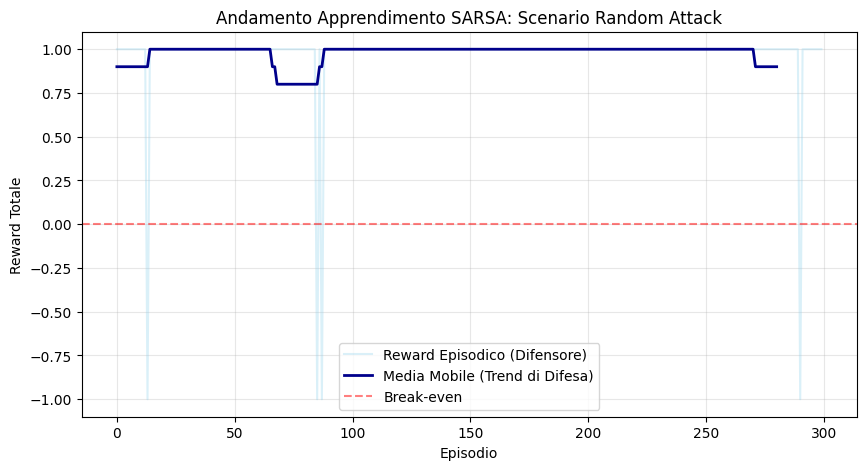

In [7]:
def moving_average(data, window_size):
    if len(data) < window_size:
        return data
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Calcolo la media mobile (finestra di 20 episodi)
ma_rewards = moving_average(sarsa_rewards, 20)

plt.figure(figsize=(10, 5))
# Uso colori che richiamano la sicurezza (come il blu) per il difensore
plt.plot(sarsa_rewards, alpha=0.3, label="Reward Episodico (Difensore)", color='skyblue')
plt.plot(ma_rewards, label="Media Mobile (Trend di Difesa)", color='darkblue', linewidth=2)

# Linea dello zero per distinguere successo (sopra livello linea) da fallimento (sotto livello linea)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label="Break-even")

plt.xlabel('Episodio')
plt.ylabel('Reward Totale')
plt.title('Andamento Apprendimento SARSA: Scenario Random Attack')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# DOUBLE DEEP Q-NETWORK DDQN PER LA PROTEZIONE DELLA RETE SANITARIA

Mentre SARSA è efficace in scenari a bassa dimensionalità, la sicurezza di una rete ospedaliera reale richiede la gestione di uno spazio degli stati vasto e complesso.
Per questo motivo, implemento un'architettura DDQN.
Infatti, l'adozione del Deep Learning permette il passaggio dalla mappatura discreta al Feature Learning: la rete neurale non isola i singoli stati, ma impara a generalizzare pattern di attacco e difesa.
Se due configurazioni di rete sono simili, il sistema è in grado di applicare una difesa coerente, superando i limiti di memoria e rigidità della Q table.

Dettagli tecnici dell'implementazione:

- Disaccoppiamento della selezione e valutazione: per mitigare il problema dell'eccessivo ottimismo nelle stime del valore Q, utilizzo due reti distinte:

   1) Policy Network: utilizzata per selezionare l'azione migliore.

   2) Target Network: utilizzata esclusivamente per valutare il valore dell'azione selezionata.L'aggiornamento periodico dei pesi dalla Policy alla Target network stabilizza l'apprendimento, rendendo le decisioni dell'agente più robuste.

- Experience Replay Buffer: l'agente memorizza le transizioni (s, a, r, s', done) in una memoria circolare. Campionando casualmente i batch di addestramento, ostacolo la correlazione temporale delle esperienze, permettendo alla rete di imparare più volte da eventi critici, come violazioni dei dati o difese critiche, senza dimenticarli prematuramente.

- Gestione dello Stato e del Reward: anche per DDQN, l'agente utilizza le funzioni patched_reset e patched_step. Questo assicura che l'input della rete sia un vettore normalizzato di 33 elementi e che il segnale di addestramento sia il reward specifico del difensore, garantendo la convergenza verso una strategia di protezione e non di attacco.

- Scenario "Maximal Attack": a differenza di SARSA, addestro DDQN contro un avversario sofisticato che analizza sistematicamente le vulnerabilità per colpire il punto più debole, fornendo un banco di prova ideale per le capacità di generalizzazione della rete neurale.


In [8]:
# CLASSE REPLAY BUFFER
class ReplayBuffer:
    """
    Memoria ciclica dell'agente. Memorizza le transizioni per
    rompere la correlazione temporale durante l'addestramento.
    """
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        # Campionamento casuale dal buffer
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = zip(*batch)
        return np.array(state), action, reward, np.array(next_state), done

    def __len__(self):
        return len(self.buffer)



# RETE NEURALE
class DQNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQNetwork, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

# OTTIMIZZAZIONE MODULARE
def optimize_model(policy_net, target_net, memory, optimizer, batch_size, gamma, device):
    if len(memory) < batch_size:
        return

    # Campionamento dal buffer
    states, actions, rewards, next_states, dones = memory.sample(batch_size)

    states = torch.FloatTensor(states).to(device)
    actions = torch.LongTensor(actions).unsqueeze(1).to(device)
    rewards = torch.FloatTensor(rewards).to(device)
    next_states = torch.FloatTensor(next_states).to(device)
    dones = torch.FloatTensor(dones).to(device)

    # Valori Q attuali
    current_q_values = policy_net(states).gather(1, actions)

    # LOGICA DOUBLE DQN: Policy e Target
    with torch.no_grad():
        next_actions = policy_net(next_states).max(1)[1].unsqueeze(1)
        next_q_values = target_net(next_states).gather(1, next_actions).squeeze(1)
        # Correzione TD-Target fornita dal docente: reward + gamma * Q_next * (1 - done)
        expected_q_values = rewards + (gamma * next_q_values * (1 - dones))

    loss = F.mse_loss(current_q_values.squeeze(), expected_q_values)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

'''VECCHIA CELLA DI TESTO'''

DOUBLE DEEP Q-NETWORK PER LA PROTEZIONE DELLA RETE SANITARIA

Mentre SARSA è efficace in ambienti con pochi stati, la sicurezza di una rete ospedaliera reale può presentare migliaia di configurazioni.
Per questo motivo, implemento un'architettura Double Deep Q-Network.

Passando al deep learning, il sistema passa all'apprendimento dalle caratteristiche (Feature Learning). Infatti, invece di mappare ogni stato come un'entità isolata , la rete neurale impara a riconoscere specifici pattern di attacco. Se due stati della rete 3 x 11 sono simili, la rete neurale è in grado di generalizzare la difesa.
Con questa scelta, supero un limite della tabella: con DDQN infatti non si è più limitati dalla memoria del dizionario della Q-Table poiché la conoscenza è compressa nei pesi dei neuroni.

L'algoritmo DDQN possiede determinate caratteristiche:

-Target Network: utilizzo due reti neurali identiche, quella Online e quella Target. La rete Online viene addestrata, mentre la rete Target viene aggiornata solo periodicamente. Questo impedisce di incorrere in un eccessivo ottimismo: il sistema potrebbe sovrastimare l'efficacia di alcune azioni solo perché ha avuto fortuna una volta. Con una seconda rete le decisioni sono più solide e meno soggette a errori di valutazione improvvisi.

-Buffer: l'agente memorizza le sue esperienze passate (stato, azione, reward, stato successivo) in una memoria e le "rilegge" casualmente. Questo rompe la correlazione tra le esperienze e permette di imparare più volte da eventi critici, come un attacco riuscito.

-Scenario Maximal Attack: a differenza di SARSA, qui addestro il difensore contro un Maximal Attacker, vale a dire un avversario che analizza le vulnerabilità per colpire sempre il punto più debole.

In [9]:
''' VECCHIA CELLA DI CODICE PRECEDENTE RISPETTO ALLA CORREZIONE

# DEFINISCO
#LA RETE NEURALE
class DQNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQNetwork, self).__init__()
        # Definisco di una rete Feed-Forward classica
        self.fc1 = nn.Linear(input_dim, 128) # primo strato nascosto
        self.fc2 = nn.Linear(128, 128)      # secondo strato nascosto
        self.fc3 = nn.Linear(128, output_dim) # output: valori Q per le 30 azioni

    def forward(self, x):
        # Uso la funzione di attivazione ReLU per introdurre non-linearità
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

#IL BUFFER DI MEMORIA
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        # Pesco casualmente un gruppo di esperienze (batch)
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = zip(*batch)
        return (np.array(state), np.array(action), np.array(reward),
                np.array(next_state), np.array(done))

    def __len__(self):
        return len(self.buffer)

#CONFIGURAZIONE PARAMETRI
input_size = 3 * 11  # la matrice 3x11 degli stati
output_size = 30     # le 30 azioni
batch_size = 64
gamma = 0.99
learning_rate = 0.001
buffer_capacity = 10000

# Inizializzo le DUE reti
policy_net = DQNetwork(input_size, output_size).to(device)
target_net = DQNetwork(input_size, output_size).to(device)
target_net.load_state_dict(policy_net.state_dict()) # Copio i pesi iniziali

optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)
memory = ReplayBuffer(buffer_capacity)

print(f"Architettura DDQN pronta: Input {input_size}, Output {output_size}")
'''

' VECCHIA CELLA DI CODICE PRECEDENTE RISPETTO ALLA CORREZIONE\n\n# DEFINISCO\n#LA RETE NEURALE\nclass DQNetwork(nn.Module):\n    def __init__(self, input_dim, output_dim):\n        super(DQNetwork, self).__init__()\n        # Definisco di una rete Feed-Forward classica\n        self.fc1 = nn.Linear(input_dim, 128) # primo strato nascosto\n        self.fc2 = nn.Linear(128, 128)      # secondo strato nascosto\n        self.fc3 = nn.Linear(128, output_dim) # output: valori Q per le 30 azioni\n\n    def forward(self, x):\n        # Uso la funzione di attivazione ReLU per introdurre non-linearità\n        x = F.relu(self.fc1(x))\n        x = F.relu(self.fc2(x))\n        return self.fc3(x)\n\n#IL BUFFER DI MEMORIA\nclass ReplayBuffer:\n    def __init__(self, capacity):\n        self.buffer = deque(maxlen=capacity)\n\n    def push(self, state, action, reward, next_state, done):\n        self.buffer.append((state, action, reward, next_state, done))\n\n    def sample(self, batch_size):\n       

## Implementazione del Ciclo di Addestramento DDQN

In questa fase, l'agente interagisce con lo scenario maximal_attack-v3.

A differenza dell'attacco casuale, qui l'avversario è programmato per sfruttare in modo sistematico le vulnerabilità della rete sanitaria. rendendo necessario un approccio di difesa molto più sofisticato e proattivo.

Il processo di ottimizzazione implementato ha i seguenti punti salienti:

- Normalizzazione e flattening: grazie al wrapper patched_reset, la matrice 3 x 11 viene automaticamente appiattita in un vettore di 33 elementi. Questo garantisce che la rete neurale riceva un input coerente e pre-processato in ogni step.

- Logica Double DQN: Per calcolare il valore atteso Q target, utilizzo il disaccoppiamento tra Policy Net e Target Net. Questa distinzione è fondamentale per stabilizzare l'apprendimento e prevenire il fenomeno della sovrastima dei valori Q, tipico del DQN standard.

- Gestione del reward del difensore: il ciclo di addestramento utilizza la funzione patched_step, che estrae correttamente il reward con indice 1. In questo modo, l'agente è guidato da un segnale di feedback che premia esclusivamente l'efficacia delle contromisure adottate.

- Epsilon-Greedy decay: L'agente inizia con un'esplorazione totale (con epsilon = 1.0) che decade del 1% a ogni episodio fino a un minimo del 5%. Questo garantisce una transizione fluida dalla scoperta casuale di strategie difensive allo sfruttamento della conoscenza consolidata nei pesi della rete.

- Sincronizzazione target network: ogni 10 episodi effettuo un update dei pesi della Target Network, copiandoli dalla Policy Network.

In [10]:
'''VECCHIO CODICE

def optimize_model():
    if len(memory) < batch_size:
        return

    # Campionamento dal Buffer
    states, actions, rewards, next_states, dones = memory.sample(batch_size)

    # Converto in tensori PyTorch
    states = torch.FloatTensor(states).to(device)
    actions = torch.LongTensor(actions).unsqueeze(1).to(device)
    rewards = torch.FloatTensor(rewards).to(device)
    next_states = torch.FloatTensor(next_states).to(device)
    dones = torch.FloatTensor(dones).to(device)

    # Calcolo dei valori Q attuali (dalla Policy Net)
    current_q_values = policy_net(states).gather(1, actions)

    # Logica DOUBLE DQN:
    # Utilizzo la Policy Net per scegliere l'azione migliore nel prossimo stato
    # Utilizzo la Target Net per calcolare il valore di quell'azione
    with torch.no_grad():
        next_actions = policy_net(next_states).max(1)[1].unsqueeze(1)
        next_q_values = target_net(next_states).gather(1, next_actions).squeeze(1)
        expected_q_values = rewards + (gamma * next_q_values * (1 - dones))

    # Calcolo la Loss e procedo con ottimizzazione
    loss = F.mse_loss(current_q_values.squeeze(), expected_q_values)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# DEFINISCO PARAMETRI AMBIENTE
env_name_complex = "idsgame-maximal_attack-v0" # Nuovo scenario più impegnativo
env_complex = gym.make(env_name_complex)
episodes_ddqn = 300
epsilon_ddqn = 1.0
epsilon_decay = 0.99
epsilon_min = 0.05
target_update = 10 # Ogni quanti episodi aggiorno la Target Net

ddqn_rewards = []

for episode in range(episodes_ddqn):
    obs_raw = env_complex.unwrapped.reset()
    state = (obs_raw[0] if isinstance(obs_raw, tuple) else obs_raw).flatten()
    total_reward = 0

    for t in range(200):
        # Seleziono azione
        if random.random() < epsilon_ddqn:
            action = env_complex.action_space.sample()
        else:
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                action = policy_net(state_tensor).max(1)[1].item()

        # Eseguo passo (con gestione multi-agente come ho fatto precedentemente in SARSA)
        try:
            results = env_complex.unwrapped.step((None, action))
        except:
            results = env_complex.unwrapped.step(action)

        next_obs, reward, done, _ = results[:4]

        # Pulisco reward (come fatto precedentemente in SARSA)
        if isinstance(reward, (tuple, list, np.ndarray)):
            reward = float(reward[0])
        else:
            reward = float(reward)

        next_state = next_obs.flatten()

        # Salvo nel Buffer
        memory.push(state, action, reward, next_state, done)

        state = next_state
        total_reward += reward

        # Ottimizzo la rete
        optimize_model()

        if done:
            break

    # Effettuo update Epsilon e Target Net
    epsilon_ddqn = max(epsilon_min, epsilon_ddqn * epsilon_decay)
    if episode % target_update == 0:
        target_net.load_state_dict(policy_net.state_dict())

    ddqn_rewards.append(total_reward)
    if (episode + 1) % 10 == 0:
        print(f"Episodio {episode+1}: Reward = {total_reward:.2f}, Epsilon = {epsilon_ddqn:.2f}")

print("Addestramento DDQN Completato.")

'''

'VECCHIO CODICE\n\ndef optimize_model():\n    if len(memory) < batch_size:\n        return\n\n    # Campionamento dal Buffer\n    states, actions, rewards, next_states, dones = memory.sample(batch_size)\n\n    # Converto in tensori PyTorch\n    states = torch.FloatTensor(states).to(device)\n    actions = torch.LongTensor(actions).unsqueeze(1).to(device)\n    rewards = torch.FloatTensor(rewards).to(device)\n    next_states = torch.FloatTensor(next_states).to(device)\n    dones = torch.FloatTensor(dones).to(device)\n\n    # Calcolo dei valori Q attuali (dalla Policy Net)\n    current_q_values = policy_net(states).gather(1, actions)\n\n    # Logica DOUBLE DQN:\n    # Utilizzo la Policy Net per scegliere l\'azione migliore nel prossimo stato\n    # Utilizzo la Target Net per calcolare il valore di quell\'azione\n    with torch.no_grad():\n        next_actions = policy_net(next_states).max(1)[1].unsqueeze(1)\n        next_q_values = target_net(next_states).gather(1, next_actions).squeeze(1)

In [11]:
# INIZIALIZZAZIONE AMBIENTE E PARAMETRI
env_complex = gym.make(ENV_NAME_MAXIMAL)

# Parametri Architettura

# Inizializzo il reset una volta per vedere la dimensione dello stato
test_state = patched_reset(env_complex)
input_size = test_state.shape[0] # Questo si adatta automaticamente
output_size = env_complex.action_space.n
batch_size = 64
gamma = 0.99
learning_rate = 0.001
buffer_capacity = 10000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# CREO GLI OGGETTI
# Creo la memoria, le reti e l'ottimizzatore prima del ciclo di addestramento
memory = ReplayBuffer(buffer_capacity)
policy_net = DQNetwork(input_size, output_size).to(device)
target_net = DQNetwork(input_size, output_size).to(device)
target_net.load_state_dict(policy_net.state_dict())
optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)

# CONFIGURAZIONE ADDESTRAMENTO
episodes_ddqn = 300
epsilon_ddqn = 1.0
epsilon_decay = 0.99
epsilon_min = 0.05
target_update = 10
ddqn_rewards = []

print(f"Inizio addestramento su: {ENV_NAME_MAXIMAL}")

# CICLO DI ADDESTRAMENTO DDQN
for episode in range(episodes_ddqn):
    # Uso il wrapper per il reset normalizzato
    state = patched_reset(env_complex)
    total_reward = 0

    for t in range(200):
        # Seleziono azione epsilon-greedy
        if random.random() < epsilon_ddqn:
            action = env_complex.action_space.sample()
        else:
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                action = policy_net(state_tensor).max(1)[1].item()

        # Step con wrapper (reward del difensore con indice 1)
        next_state, reward, done, _ = patched_step(env_complex, action)

        # Salvo esperienza
        memory.push(state, action, reward, next_state, done)

        state = next_state
        total_reward += reward

        # Ottimizzo
        optimize_model(policy_net, target_net, memory, optimizer, batch_size, gamma, device)

        if done:
            break

    # Update epsilon
    epsilon_ddqn = max(epsilon_min, epsilon_ddqn * epsilon_decay)

    # Sincronizzo periodicamente Target Network
    if episode % target_update == 0:
        target_net.load_state_dict(policy_net.state_dict())

    ddqn_rewards.append(total_reward)

    if (episode + 1) % 10 == 0:
        print(f"Episodio {episode+1}: Reward = {total_reward:.2f}, Epsilon = {epsilon_ddqn:.2f}")

print("Addestramento DDQN Completato con successo.")

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment idsgame-maximal_attack-v3 is out of date. You should consider upgrading to version `v21`.
  logger.deprecation(


Inizio addestramento su: idsgame-maximal_attack-v3
Episodio 10: Reward = 1.00, Epsilon = 0.90
Episodio 20: Reward = -1.00, Epsilon = 0.82
Episodio 30: Reward = 1.00, Epsilon = 0.74
Episodio 40: Reward = 1.00, Epsilon = 0.67
Episodio 50: Reward = -1.00, Epsilon = 0.61
Episodio 60: Reward = 1.00, Epsilon = 0.55
Episodio 70: Reward = -1.00, Epsilon = 0.49
Episodio 80: Reward = 1.00, Epsilon = 0.45
Episodio 90: Reward = 1.00, Epsilon = 0.40
Episodio 100: Reward = -1.00, Epsilon = 0.37
Episodio 110: Reward = 1.00, Epsilon = 0.33
Episodio 120: Reward = -1.00, Epsilon = 0.30
Episodio 130: Reward = 1.00, Epsilon = 0.27
Episodio 140: Reward = 1.00, Epsilon = 0.24
Episodio 150: Reward = 1.00, Epsilon = 0.22
Episodio 160: Reward = 1.00, Epsilon = 0.20
Episodio 170: Reward = 1.00, Epsilon = 0.18
Episodio 180: Reward = -1.00, Epsilon = 0.16
Episodio 190: Reward = 1.00, Epsilon = 0.15
Episodio 200: Reward = 1.00, Epsilon = 0.13
Episodio 210: Reward = 1.00, Epsilon = 0.12
Episodio 220: Reward = 1.00,

## DDQN nello scenario random attack

Come richiesto, vado ad implementare il DDQN anche per lo scenario di random attack. Facendo ciò, sarà possibile anche visualizzare un confronto tra SARSA e DDQN nel medesimo scenario con lo stesso numero di episodi.

In [12]:
'''vecchio codice

# Uso lo stesso ambiente di SARSA
env_random = gym.make("idsgame-random_attack-v0")

episodes_ddqn_random = 300
epsilon_ddqn = 1.0
ddqn_random_rewards = []

# Resetto la rete per partire da zero
policy_net = DQNetwork(input_size, output_size).to(device)
target_net = DQNetwork(input_size, output_size).to(device)
target_net.load_state_dict(policy_net.state_dict())

# Resetto il buffer per eliminare ciò che deriva dal Maximal Attack
memory = ReplayBuffer(buffer_capacity)

# Resetto l'optimizer così da collegarlo alla nuova Policy Net
optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)

for episode in range(episodes_ddqn_random):
    obs_raw = env_random.unwrapped.reset()
    state = (obs_raw[0] if isinstance(obs_raw, tuple) else obs_raw).flatten()
    total_reward = 0

    for t in range(200):
        # Seleziono Azione
        if random.random() < epsilon_ddqn:
            action = env_random.action_space.sample()
        else:
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                action = policy_net(state_tensor).max(1)[1].item()

        # Eseguo passo
        try:
            results = env_random.unwrapped.step((None, action))
        except:
            results = env_random.unwrapped.step(action)

        next_obs, reward, done, _ = results[:4]

        # Pulisco reward
        if isinstance(reward, (tuple, list, np.ndarray)):
            reward = float(reward[0])
        else:
            reward = float(reward)

        next_state = next_obs.flatten()
        memory.push(state, action, reward, next_state, done)

        state = next_state
        total_reward += reward
        optimize_model()

        if done:
            break

    epsilon_ddqn = max(epsilon_min, epsilon_ddqn * epsilon_decay)
    if episode % target_update == 0:
        target_net.load_state_dict(policy_net.state_dict())

    ddqn_random_rewards.append(total_reward)
    if (episode + 1) % 20 == 0:
        print(f"Episodio {episode+1}: Reward = {total_reward:.2f}")

print("Addestramento DDQN (scenario Random Attack) Completato!")

'''

'vecchio codice \n\n# Uso lo stesso ambiente di SARSA\nenv_random = gym.make("idsgame-random_attack-v0")\n\nepisodes_ddqn_random = 300\nepsilon_ddqn = 1.0\nddqn_random_rewards = []\n\n# Resetto la rete per partire da zero\npolicy_net = DQNetwork(input_size, output_size).to(device)\ntarget_net = DQNetwork(input_size, output_size).to(device)\ntarget_net.load_state_dict(policy_net.state_dict())\n\n# Resetto il buffer per eliminare ciò che deriva dal Maximal Attack\nmemory = ReplayBuffer(buffer_capacity)\n\n# Resetto l\'optimizer così da collegarlo alla nuova Policy Net\noptimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)\n\nfor episode in range(episodes_ddqn_random):\n    obs_raw = env_random.unwrapped.reset()\n    state = (obs_raw[0] if isinstance(obs_raw, tuple) else obs_raw).flatten()\n    total_reward = 0\n\n    for t in range(200):\n        # Seleziono Azione\n        if random.random() < epsilon_ddqn:\n            action = env_random.action_space.sample()\n        else

In [13]:
# ADDESTRAMENTO DDQN (SCENARIO RANDOM ATTACK)

# Utilizzo l'ambiente specifico per il Random Attack
env_random = gym.make(ENV_NAME_RANDOM)

# Numero di episodi per il confronto con SARSA

episodes_ddqn_random = 300

# RILEVAZIONE DINAMICA DIMENSIONE STATO
# Necessario per evitare errori di dimensione tra scenari diversi
test_state_random = patched_reset(env_random)
input_size_random = test_state_random.shape[0]
output_size_random = env_random.action_space.n

# RESET COMPLETO DELL'AGENTE
# Inizializzo nuovamente la rete con la dimensione corretta
policy_net = DQNetwork(input_size_random, output_size_random).to(device)
target_net = DQNetwork(input_size_random, output_size_random).to(device)
target_net.load_state_dict(policy_net.state_dict())

# Svuoto il buffer per non inquinare l'addestramento con i dati del Maximal Attack
memory = ReplayBuffer(buffer_capacity)

# Reset dell'optimizer e parametro epsilon
optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)
epsilon_ddqn = 1.0
ddqn_random_rewards = []

print(f"Inizio addestramento comparativo su: {ENV_NAME_RANDOM}")
print(f"Dimensione stato rilevata: {input_size_random}")

for episode in range(episodes_ddqn_random):
    state = patched_reset(env_random)
    total_reward = 0

    for t in range(200):
        # Seleziono azione epsilon-greedy
        if random.random() < epsilon_ddqn:
            action = env_random.action_space.sample()
        else:
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                action = policy_net(state_tensor).max(1)[1].item()

        # Step tramite wrapper
        next_state, reward, done, _ = patched_step(env_random, action)

        # Salvataggio nel buffer
        memory.push(state, action, reward, next_state, done)

        state = next_state
        total_reward += reward

        # Ottimizzazione
        optimize_model(policy_net, target_net, memory, optimizer, batch_size, gamma, device)

        if done:
            break

    # Update parametri
    epsilon_ddqn = max(epsilon_min, epsilon_ddqn * epsilon_decay)
    if episode % target_update == 0:
        target_net.load_state_dict(policy_net.state_dict())

    ddqn_random_rewards.append(total_reward)
    if (episode + 1) % 20 == 0:
        print(f"Episodio {episode+1}: Reward = {total_reward:.2f}, Epsilon = {epsilon_ddqn:.2f}")

print("Addestramento DDQN (scenario Random Attack) Completato!")

Inizio addestramento comparativo su: idsgame-random_attack-v3
Dimensione stato rilevata: 88


/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment idsgame-random_attack-v3 is out of date. You should consider upgrading to version `v21`.
  logger.deprecation(


Episodio 20: Reward = 1.00, Epsilon = 0.82
Episodio 40: Reward = 1.00, Epsilon = 0.67
Episodio 60: Reward = 1.00, Epsilon = 0.55
Episodio 80: Reward = 1.00, Epsilon = 0.45
Episodio 100: Reward = 1.00, Epsilon = 0.37
Episodio 120: Reward = 1.00, Epsilon = 0.30
Episodio 140: Reward = 1.00, Epsilon = 0.24
Episodio 160: Reward = -1.00, Epsilon = 0.20
Episodio 180: Reward = 1.00, Epsilon = 0.16
Episodio 200: Reward = 1.00, Epsilon = 0.13
Episodio 220: Reward = 1.00, Epsilon = 0.11
Episodio 240: Reward = 1.00, Epsilon = 0.09
Episodio 260: Reward = 1.00, Epsilon = 0.07
Episodio 280: Reward = 1.00, Epsilon = 0.06
Episodio 300: Reward = -1.00, Epsilon = 0.05
Addestramento DDQN (scenario Random Attack) Completato!


# ANALISI COMPARATIVA DELLE PERFORMANCE SU SCENARIO DI RANDOM ATTACK

In questa fase finale, metto a confronto SARSA e DDQN nello scenario di attacco casuale. Entrambi gli agenti sono stati addestrati per 300 episodi utilizzando i medesimi wrapper di normalizzazione, garantendo una base di confronto rigorosa ed equa.

Attraverso questo confronto posso valutare tre pilastri fondamentali:

- Sample Efficiency: osservo se l'approccio tabellare SARSA, grazie alla sua semplicità strutturale, riesce a mappare le contromisure efficaci più velocemente rispetto alla rete neurale, che richiede invece una fase iniziale di ottimizzazione dei pesi.

- Stabilità e convergenza: verifico quale dei due modelli mantiene prestazioni più costanti. Con la correzione del TD-target tramite il termine (1 - done), mi aspetto una convergenza più solida per entrambi i modelli rispetto alla versione precedente, evitando la propagazione di valori Q errati oltre lo stato terminale.

- Generalizzazione e capacità di difesa: discuto l'efficacia del Deep Learning nel mappare lo stato della rete ospedaliera. Mentre la Q table è vincolata dal fatto che ogni stato nuovo è un'entità isolata, il DDQN dovrebbe teoricamente riconoscere pattern comuni tra stati simili, offrendo una difesa più resiliente.

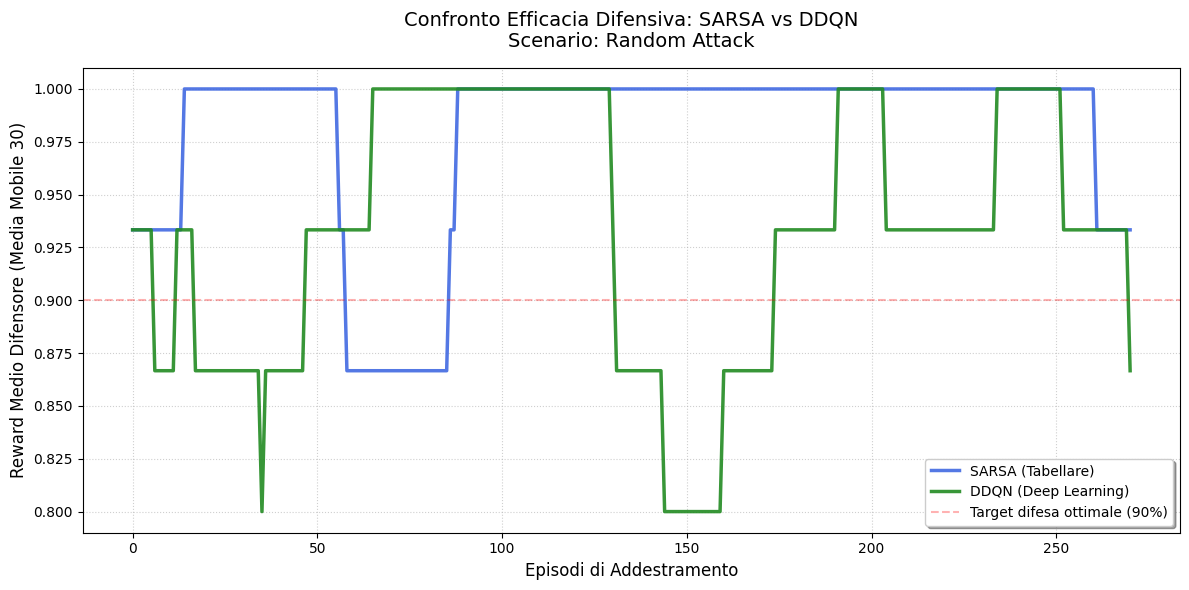

   RISULTATI FINALI (Ultimi 50 Episodi)
SARSA | Reward Medio: 0.96 (±0.28)
DDQN  | Reward Medio: 0.92 (±0.39)


In [14]:
import matplotlib.pyplot as plt

def moving_average(data, window_size=30):
    if len(data) < window_size:
        return data
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Calcolo medie mobili (finestra di 30 episodi per una maggiore pulizia visiva)
ma_sarsa = moving_average(sarsa_rewards, 30)
ma_ddqn_random = moving_average(ddqn_random_rewards, 30)

plt.figure(figsize=(12, 6))

# Visualizzo i trend
plt.plot(ma_sarsa, label="SARSA (Tabellare)", color='royalblue', linewidth=2.5, alpha=0.9)
plt.plot(ma_ddqn_random, label="DDQN (Deep Learning)", color='forestgreen', linewidth=2.5, alpha=0.9)

# Linea di riferimento (Break-even tra compromissione e difesa)
plt.axhline(y=0.9 , color='red', linestyle='--', alpha=0.3, label="Target difesa ottimale (90%)")

# Formattazione avanzata
plt.title('Confronto Efficacia Difensiva: SARSA vs DDQN\nScenario: Random Attack', fontsize=14, pad=15)
plt.xlabel('Episodi di Addestramento', fontsize=12)
plt.ylabel('Reward Medio Difensore (Media Mobile 30)', fontsize=12)
plt.legend(loc='best', frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# ANALISI NUMERICA STATISTICA
final_sarsa_mean = np.mean(sarsa_rewards[-50:])
final_ddqn_mean = np.mean(ddqn_random_rewards[-50:])
final_sarsa_std = np.std(sarsa_rewards[-50:])
final_ddqn_std = np.std(ddqn_random_rewards[-50:])

print(f"{'='*45}")
print(f"   RISULTATI FINALI (Ultimi 50 Episodi)")
print(f"{'='*45}")
print(f"SARSA | Reward Medio: {final_sarsa_mean:.2f} (±{final_sarsa_std:.2f})")
print(f"DDQN  | Reward Medio: {final_ddqn_mean:.2f} (±{final_ddqn_std:.2f})")
print(f"{'='*45}")

Il confronto finale evidenzia come entrambi gli agenti siano stati in grado di superare ampiamente la soglia di difesa ottimale del 90%, pur con dinamiche di apprendimento differenti:

- Efficienza tabellare di SARSA: in questa sessione, SARSA si è dimostrato l'agente più costante nel mantenere la massima efficacia difensiva. Una volta stabilizzata la Q table, l'agente ha mantenuto un reward di 1.0 per blocchi estesi di episodi, dimostrando che, in un ambiente a stati finiti come quello simulato, la semplicità dell'approccio tabellare offre una garanzia di sicurezza priva di interferenze.

- Capacità e oscillazioni del DDQN: il DDQN raggiunge regolarmente il reward massimo, confermando la sua capacità di mappare correttamente lo stato della rete ospedaliera. Tuttavia, si osservano oscillazioni più frequenti rispetto a SARSA, con cali temporanei verso l'80%. Questo comportamento è tipico delle reti neurali, soggette a piccoli aggiustamenti dei pesi che possono temporaneamente destabilizzare la politica ottimale prima di recuperare nuovamente.

- Resilienza complessiva: è degno di nota come entrambi i modelli riescano a recuperare rapidamente da eventuali errori di difesa. Il DDQN, in particolare, mostra una notevole capacità di "rimbalzo", tornando istantaneamente al reward di 1.0 dopo ogni oscillazione, segno di un'architettura neurale ben addestrata.

In conclusione, in questa simulazione, SARSA ottiene un leggero vantaggio in termini di stabilità pura, riuscendo a mantenere la politica perfetta più a lungo. Il DDQN si conferma uno strumento estremamente potente e capace di eguagliare le prestazioni massime, ma la sua natura stocastica richiede una calibrazione più fine per eliminare le micro-oscillazioni residue. Entrambi i modelli, comunque, garantiscono un livello di protezione del sistema sanitario eccellente, operando stabilmente nella zona di massima resilienza.